# Solar PV Hotspot Detection (Binary Classification)
**Model:** DenseNet201 (Transfer Learning + Fine-tuning)  
**Dataset:** `seyeddd/solar_pv_single_hotspot_clean_images` (Hugging Face)  
**Tracking:** MLflow + SHAP Explainability  
**Goal:** Classify thermal PV images into **clean** vs **single_hotspot**.

---

## Notebook Chapters
1. Environment Setup  
2. Necessary Imports  
3. Dataset Download and Extraction  
4. Data Preprocessing and Augmentation  
5. Model Building (Base: Frozen Backbone)  
6. Training Controls (Callbacks)
7. Evaluation + MLflow Metric Logging
8. Plotting Utilities
9. MLflow Params
10. Explainability (SHAP)
11. Training + Evaluation (Base Model - Frozen Backbone)
12. Model Architecture
13. Fine-tuning (Partial Unfreeze)
14. Training + Evaluation (Fine-tuned Model)
15. Conclusion

## 1. Environment Setup

In [1]:
!pip install datasets huggingface_hub --upgrade
!pip install pydot graphviz
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 1.8 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 2.3 MB/s  0:00:0036m-:--:--
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.7.1
    Uninstalling huggingface_hub-1.7.1:
      Successfully uninstalled huggingface_hub-1.7.1
  Attempting uninstall: datasets━━━━━━━━━━━━━━━━ 0/2 [huggingface_hub]
    Found existing installation: datasets 4.8.3m 0/2 [huggingface_hub]
    Uninstalling datasets-4.8.3:━━━━━━━━━━━━ 0/2 [huggingface_hub]
      Successfully uninstalled datasets-4.8.3 0/2 [huggingface_hub]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [datasets]1/2 [datasets]


## 2. Necessary Imports

This section imports all required libraries and sets random seeds to ensure reproducible results across runs.

In [2]:
import os

# Data Analysis and Metric Plots
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

# Image precessing
from collections import Counter
from PIL import Image
import cv2

# Sci-kit Learn metrics
from sklearn.metrics import  (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve, log_loss, brier_score_loss, average_precision_score)

# TensorFlow: Building the model
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.metrics import Precision, Recall, AUC
from sklearn.calibration import calibration_curve

# Visualize the model
from tensorflow.keras.utils import plot_model
import visualkeras

# Load the dataset from hugging face
from huggingface_hub import hf_hub_download

import zipfile

# Model interpretability
import shap
import mlflow

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

/Users/seyedrumaiz/Library/Mobile Documents/com~apple~CloudDocs/DSGP/solar-panel-fault-mapping/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Reproducability
np.random.seed(42)
tf.random.set_seed(42)

## 3. Dataset Download and Extraction

The cleaned dataset ZIP was downloaded from Hugging Face using `hf_hub_download`, then extract it to a local folder (`dataset/`).
Expected structure:

- dataset/train/single_hotspot
- dataset/train/clean
- dataset/valid/single_hotspot
- dataset/valid/clean
- dataset/test/single_hotspot
- dataset/test/clean

In [4]:
# Download the zip file
zip_path = hf_hub_download(
    repo_id="seyeddd/solar_pv_single_hotspot_clean_images",
    filename="cleaned_dataset.zip",
    repo_type="dataset"
)

In [5]:
# Extract to a local folder
extract_dir = "dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

In [6]:
# Check folder structure
os.listdir(extract_dir)

['valid', 'test', 'train']

## 4. Data Preprocessing and Augmentation

A custom preprocessing pipeline was applied:

- Convert to grayscale
- Gaussian Blur (noise reduction)
- Normalize to [0,1]
- Convert back to 3 channels (required by DenseNet201)

Augmentation was also applied to the **training** set to increase the diversity of the images and reduce overfitting.

In [7]:
# Constants used throughout
IMG_SIZE = (224,224)
BATCH_SIZE = 64
EPOCHS = 20

In [8]:
# Directories
base_dir = "dataset"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")
valid_dir = os.path.join(base_dir, "valid")

In [9]:
def preprocess(img) -> np.ndarray:
    """
    Apply image-specific preprocessing steps:
    1) Convert to grayscale (if RGB)
    2) Gaussian blur for noise reduction
    3) Normalize pixel values to [0,1]
    4) Convert back to 3 channels for DenseNet input

    Args:
        img (np.ndarray): Image array from generator.

    Returns:
        np.ndarray: Preprocessed image with shape (H, W, 3) float32.
    """
    # Convert to grayscale if RGB
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img

    # Apply Gaussian Blur to reduce noise
    img_blurred = cv2.GaussianBlur(img_gray, ksize=(3,3), sigmaX=0)

    # Normalize to [0, 1]
    img_normalized = img_blurred / 255.0

    # Convert to 3 channels
    if img_normalized.ndim == 2:
        img_normalized = np.stack([img_normalized]*3, axis=-1)

    return img_normalized


In [10]:
# Data generators to normalize the images with augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess,
    rotation_range=10,
    shear_range=0.01,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation & Test generator (no augmentation)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess
)

In [11]:
# Define data gens
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=42
)

val_gen = val_test_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 2742 images belonging to 2 classes.
Found 649 images belonging to 2 classes.
Found 650 images belonging to 2 classes.


In [12]:
# Display the information for each gen
print(f"Training samples: {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Test samples: {test_gen.samples}")
print(f"Classes: {train_gen.class_indices}")

Training samples: 2742
Validation samples: 649
Test samples: 650
Classes: {'clean': 0, 'single_hotspot': 1}


### 4.1 Visualize Augmentation

Visualizations were done on the same training image to identify the changes under the augmentation settings (rotation, zoom, flip etc.) to confirm augmentation behaves as expected.

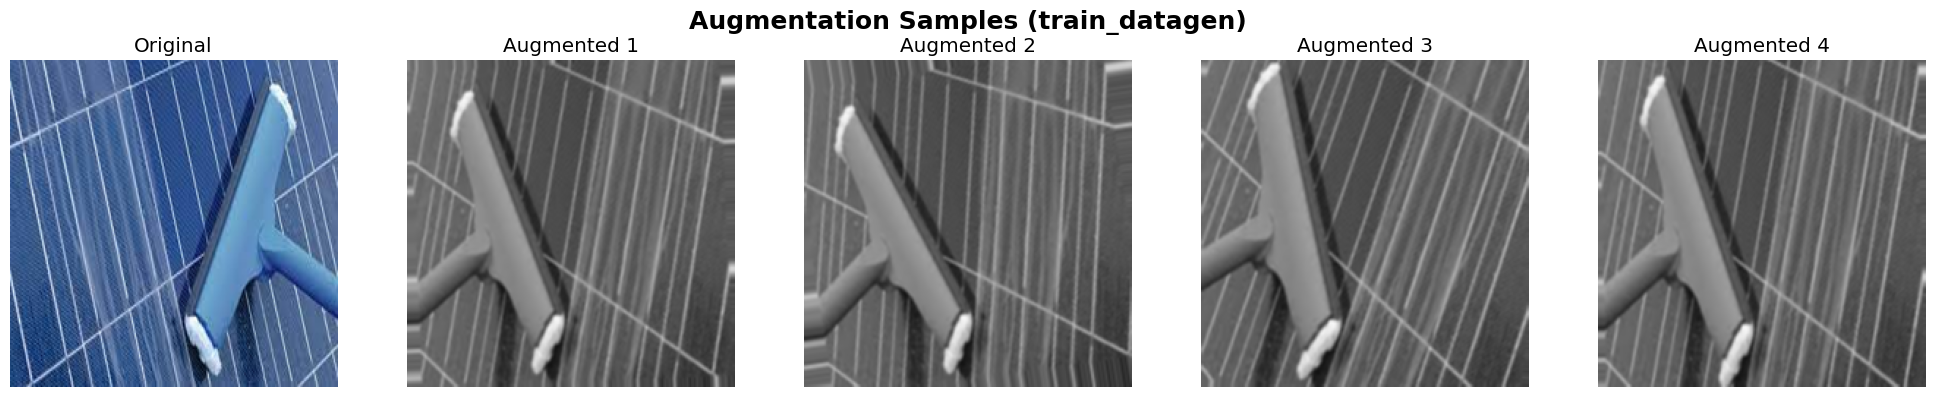

In [13]:
# Pick a sample image path (from first class folder)
sample_class = list(train_gen.class_indices.keys())[0]
sample_img_path = os.path.join(
    train_dir,
    sample_class,
    os.listdir(os.path.join(train_dir, sample_class))[0]
)

sample_img = Image.open(sample_img_path).convert("RGB").resize(IMG_SIZE)
sample_array = np.expand_dims(np.array(sample_img), axis=0)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(sample_img)
axes[0].set_title("Original")
axes[0].axis("off")

for i, batch in enumerate(train_datagen.flow(sample_array, batch_size=1, shuffle=False)):
    aug = batch[0]
    axes[i+1].imshow(aug)
    axes[i+1].set_title(f"Augmented {i+1}")
    axes[i+1].axis("off")

    if i == 3:
        break

plt.suptitle("Augmentation Samples (train_datagen)", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Model Building (Base: Frozen Backbone)

In this chapter, we build a binary image classifier using **DenseNet201** as a pretrained feature extractor (ImageNet weights).  
The backbone is initially **frozen**, and only the custom classification head is trained.  

### Architecture (High level)

- DenseNet201 backbone (frozen)
- Global Average Pooling
- Dense Layers with Batch Normalization
- Sigmoid output for binary classification (`clean` vs `single_hotspot`)

In [14]:
# Get the DenseNet201
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

In [15]:
inputs = tf.keras.Input(shape=(224,224,3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.BatchNormalization()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

In [16]:
# Compile model with relevant metrics
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy',
             Precision(name="precision"),
             Recall(name="recall"),
             AUC(name="auc")]
)

In [17]:
# Summary of the model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet201 (Functional)        │ (None, 7, 7, 1920)     │    18,321,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1920)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       245,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,579,137 (70.87 MB)

 Trainable params: 256,705 (1002.75 KB)

 Non-trainable params: 18,322,432 (69.89 MB)

## 6. Training Controls (Callbacks)

We use **Early Stopping** monitored on validation AUC (`val_auc`) to prevent overfitting.  

- `patience=5`: training stops if val AUC doesn't improve for 5 epochs.
- `restore_best_weights=True`: restores best-performing weights automatically.

In [18]:
earlystop = EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max')

class MLflowKerasCallback(tf.keras.callbacks.Callback):
    """
    Keras callback to log epoch-level metrics to MLflow automatically.
    """
    def on_epoch_end(self, epoch, logs=None):
        if logs:
            # Convert logs to float for MLflow compatability
            mlflow.log_metrics({k: float(v) for k, v in logs.items()}, step=epoch)

## 7. Evaluation + MLflow Metric Logging

This chapter evaluates the model on the **test** set and logs:

- Standard Keras evaluation metrics (loss, accuracy, precision, recall, auc)
- Log loss (probabilistic quality)
- PR-AUC (Average Precision)
- KS statistic (seperation power)
- Brier score (calibration quality)

The function returns `y_true` and predicted probabilities for later plots.

In [19]:
def eval_and_log_all(model, test_gen, run_prefix="base"):
    test_gen.reset()
    results = model.evaluate(test_gen, return_dict=True, verbose=0)
    mlflow.log_metrics({f"{run_prefix}_test_{k}": float(v) for k, v in results.items()})

    test_gen.reset()
    y_pred_prob = model.predict(test_gen).ravel()
    y_true = test_gen.classes

    # Log Loss
    ll = log_loss(y_true, y_pred_prob)
    mlflow.log_metric(f"{run_prefix}_test_log_loss", float(ll))

    # PR AUC
    pr_auc = average_precision_score(y_true, y_pred_prob)
    mlflow.log_metric(f"{run_prefix}_test_pr_auc", float(pr_auc))

    # KS statistic
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    ks = float(np.max(tpr - fpr))
    mlflow.log_metric(f"{run_prefix}_test_ks", ks)

    # Brier score (calibration quality)
    brier = brier_score_loss(y_true, y_pred_prob)
    mlflow.log_metric(f"{run_prefix}_test_brier", float(brier))

    return y_true, y_pred_prob

## 8. Plotting Utilities

We generate and log standard diagnostic plots:

- Accuracy vs Epoch
- Loss vs Epoch
- AUC vs Epoch
- Confusion Matrix
- ROC Curve
- Precision-Recall Curve
- Calibration Curve
- KS Chart

Each plot is saved to MLflow as an artifact for experiment tracking.

In [20]:
def plot_ks_chart(y_true, y_pred_proba, model_name, filename):
  """
  Plots KS Chart for binary classification of a model.
  """

  # Calculate KS Statistic
  fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
  ks_values = tpr - fpr
  ks_statistic = np.max(ks_values)
  ks_idx = np.argmax(ks_values)
  ks_threshold = thresholds[ks_idx]

  # Create dataframe for plotting
  df_ks = pd.DataFrame({
      'Thresholds': thresholds,
      'TPR': tpr,
      'FPR': fpr,
      'KS': ks_values
  })

  # Plot
  plt.figure(figsize=(10,6))
  sns.lineplot(x='Thresholds', y='TPR', data=df_ks, label='True Positive Rate (TPR)', color='blue')
  sns.lineplot(x='Thresholds', y='FPR', data=df_ks, label='False Positive Rate (FPR)', color='red')

  # Shade the KS region
  plt.fill_between(df_ks['Thresholds'], df_ks['TPR'], df_ks['FPR'], # x coordinates, y1, y2
                   where=(df_ks['TPR'] >= df_ks['FPR']),
                   color='gray', alpha=0.2, interpolate=True) # interpolate to make it smooth, else leaves small gaps and underestimates the KS area

  # Mark KS point
  plt.scatter(ks_threshold, tpr[ks_idx], color='green', s=50, label=f'KS Point ({ks_statistic:.3f})')
  plt.scatter(ks_threshold, fpr[ks_idx], color='green', s=50)

  # Style the plot
  plt.title(f"KS Chart - {model_name}", fontsize=16, fontweight='bold')
  plt.xlabel("Thresholds")
  plt.ylabel("Cumulative Percentage")
  plt.xlim([0,1])
  plt.ylim([0,1])
  plt.grid(True)
  plt.legend()
  mlflow.log_figure(plt.gcf(), filename)
  plt.show()
  plt.close()

In [21]:
def plot_accuracy(history, title, filename):
    plt.figure(figsize=(10,4))
    plt.plot(history.history["accuracy"], label="train_acc")
    plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    mlflow.log_figure(plt.gcf() ,filename)
    plt.show()
    plt.close()

In [22]:
def plot_loss(history, title, filename):
    plt.figure(figsize=(10,4))
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    mlflow.log_figure(plt.gcf(), filename)
    plt.show()
    plt.close()

In [23]:
def plot_auc(history, title, filename):
    plt.figure(figsize=(10,4))
    plt.plot(history.history["auc"], label="train_auc")
    plt.plot(history.history["val_auc"], label="val_auc")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend()
    plt.grid(True)
    mlflow.log_figure(plt.gcf() ,filename)
    plt.show()
    plt.close()

In [24]:
def get_classification_report(y_true, y_pred, class_indices, filename):
    names = list(class_indices.keys())
    report = classification_report(y_true, y_pred, target_names=names)
    print(report)
    with open(filename, "w") as f:
        f.write(report)
    mlflow.log_artifact(filename)

In [25]:
def plot_confusion_matrix(y_true, y_pred, class_indices, filename, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=list(class_indices.keys()))
    disp.plot(cmap=plt.cm.Reds)
    plt.title(title)
    mlflow.log_figure(plt.gcf(), filename)
    plt.show()
    plt.close()

In [26]:
def plot_roc_curve(y_true, y_pred_prob, title, filename):
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr)
    plt.plot([0,1], [0,1], linestyle="--")
    plt.title(title)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.grid(True)
    mlflow.log_figure(plt.gcf(), filename)
    plt.show()
    plt.close()

In [27]:
def plot_pr_curve(y_true, y_pred_prob, title, filename):
    precision, recall, _ = precision_recall_curve(y_true, y_pred_prob)
    ap = average_precision_score(y_true, y_pred_prob)

    plt.figure(figsize=(8,6))
    plt.plot(recall, precision, label=f"AP={ap:.4f}")
    plt.title(title)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid(True)
    plt.legend()
    mlflow.log_figure(plt.gcf() , filename)
    plt.show()
    plt.close()

In [28]:
def plot_calibration_curve(y_true, y_pred_prob, title, filename):
    prob_true, prob_pred = calibration_curve(y_true, y_pred_prob, n_bins=10)
    plt.figure(figsize=(8,6))
    plt.plot(prob_pred, prob_true, marker="o")
    plt.plot([0,1],[0,1],"--")
    plt.title(title)
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.grid(True)
    mlflow.log_figure(plt.gcf() , filename)
    plt.show()
    plt.close()

## 9. MLflow Params

We log important experiment parameters so each run is reproducible:

- Image size, batch size, epochs
- Backbone, whether frozen or trainable
- Optimizer + loss
- Early stopping configuration

In [29]:
def log_params():
    mlflow.log_params({
    "IMG_SIZE": str(IMG_SIZE),
    "BATCH_SIZE": BATCH_SIZE,
    "EPOCHS": EPOCHS,
    "base_model": "DenseNet201",
    "base_trainable": False,
    "optimizer": "Adam",
    "loss": "binary_crossentropy",
    "earlystop_monitor": "val_auc",
    "earlystop_patience": 5,
    })

## 10. Explainability (SHAP)

We use **SHAP GradientExplainer** to visualize which pixels contributed most to the model's decision using a **SHAP image plot**.

### Steps:
1. Select a background images from the training generator
2. Select a small batch of test images to explain
3. Compute SHAP values
4. Log combined + per-image SHAP plots to MLflow

In [30]:
def log_shap_images_to_mlflow(
    model,
    train_gen,
    test_gen,
    run_prefix: str = "base",
    n_background: int = 50,
    n_explain: int = 10,
    artifact_dir: str = "shap_artifacts",
):
    """
    Build a SHAP GradientExplainer using background images from train_gen,
    explain n_explain test images from test_gen, and log SHAP plots to MLflow.
    """

    # Reset generators for consistent batches
    train_gen.reset()
    test_gen.reset()

    # Background images
    background_images, _ = next(train_gen)
    background_images = background_images[:n_background]

    # Samples to explain
    test_images, test_labels = next(test_gen)
    test_images = test_images[:n_explain]
    test_labels = test_labels[:n_explain]

    # Explainer
    explainer = shap.GradientExplainer(model, background_images)

    # SHAP values
    shap_values = explainer.shap_values(test_images)
    # Binary classifiers often return [array]; unwrap safely
    if isinstance(shap_values, list) and len(shap_values) > 0:
        shap_values = shap_values[0]

    # Predictions (probabilities)
    pred_probs = model.predict(test_images, verbose=0).ravel()

    # Log summary params
    mlflow.log_param(f"{run_prefix}_shap_n_background", int(len(background_images)))
    mlflow.log_param(f"{run_prefix}_shap_n_explain", int(len(test_images)))

    # Combined plot
    plt.close("all")
    shap.image_plot(shap_values, test_images, show=False)
    mlflow.log_figure(
        plt.gcf(),
        f"{artifact_dir}/{run_prefix}_shap_combined.png"
    )
    plt.close("all")

    # Per-image plots + metrics
    for i in range(len(test_images)):
        mlflow.log_metric(f"{run_prefix}_shap_img{i}_pred_prob", float(pred_probs[i]))
        mlflow.log_metric(f"{run_prefix}_shap_img{i}_true_label", float(test_labels[i]))

        plt.close("all")
        shap.image_plot(shap_values[i:i+1], test_images[i:i+1], show=False)

        mlflow.log_figure(
            plt.gcf(),
            f"{artifact_dir}/{run_prefix}_shap_img{i}_p{pred_probs[i]:.3f}.png"
        )
        plt.close("all")

    # Reset generators back
    train_gen.reset()
    test_gen.reset()

## 11. Training + Evaluation (Base Model - Frozen Backbone)

We train the classification head while keeping DenseNet201 frozen.

After training we:
- Log learning curves (accuracy/loss/auc)
- Evaluate on test set
- Generate diagnostic plots
- Compute SHAP explanations
- Save the model and log it as an MLflow artifact.

2026/03/27 14:37:19 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/03/27 14:37:19 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/03/27 14:37:19 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/03/27 14:37:19 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/03/27 14:37:19 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/03/27 14:37:19 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/03/27 14:37:19 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/27 14:37:20 INFO mlflow.store.db.utils: Updating database tables
2026/03/27 14:37:20 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/27 14:37:20 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/03/27 14:37:20 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2026/03/27 14:3

Epoch 1/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 204s 5s/step - accuracy: 0.9621 - auc: 0.9953 - loss: 0.1269 - precision: 0.9847 - recall: 0.9554 - val_accuracy: 0.9908 - val_auc: 0.9997 - val_loss: 0.1078 - val_precision: 0.9950 - val_recall: 0.9900
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 216s 5s/step - accuracy: 0.9964 - auc: 0.9999 - loss: 0.0253 - precision: 0.9966 - recall: 0.9977 - val_accuracy: 0.9954 - val_auc: 0.9998 - val_loss: 0.0475 - val_precision: 0.9950 - val_recall: 0.9975
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 230s 5s/step - accuracy: 0.9985 - auc: 1.0000 - loss: 0.0145 - precision: 0.9989 - recall: 0.9989 - val_accuracy: 0.9969 - val_auc: 0.9999 - val_loss: 0.0252 - val_precision: 0.9975 - val_recall: 0.9975
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 221s 5s/step - accuracy: 0.9985 - auc: 1.0000 - loss: 0.0086 - precision: 0.9989 - recall: 0.9989 - val_accuracy: 0.9954 - val_auc: 0.9999 - val_loss: 0.0178 - val_precision: 0.9950 - val_recall: 0.9975
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━

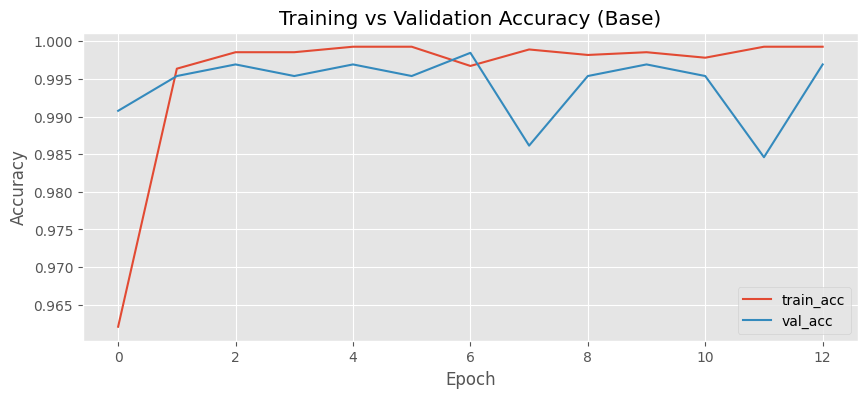

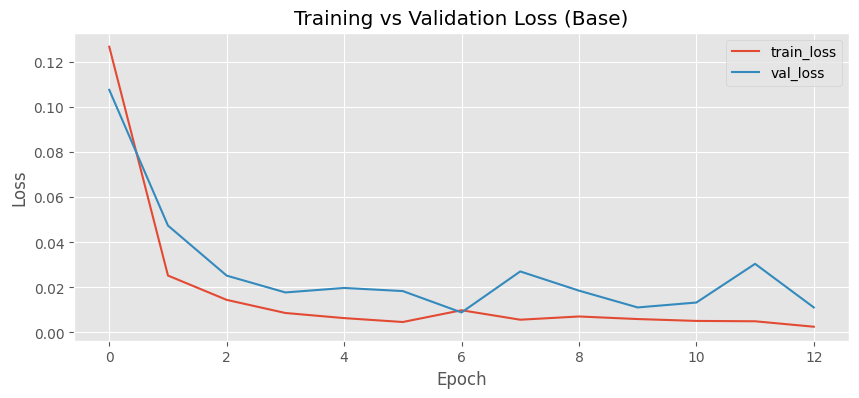

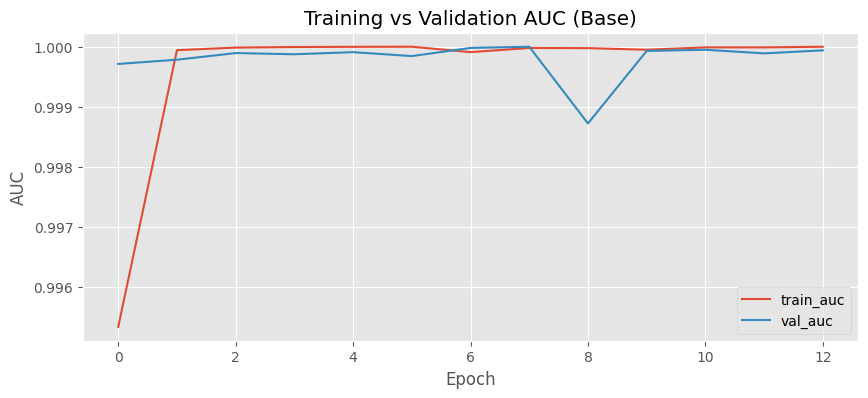

11/11 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step
                precision    recall  f1-score   support

         clean       0.98      1.00      0.99       250
single_hotspot       1.00      0.99      0.99       400

      accuracy                           0.99       650
     macro avg       0.99      0.99      0.99       650
  weighted avg       0.99      0.99      0.99       650



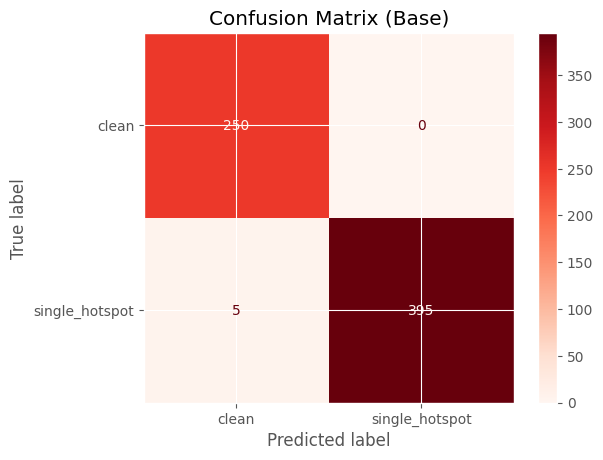

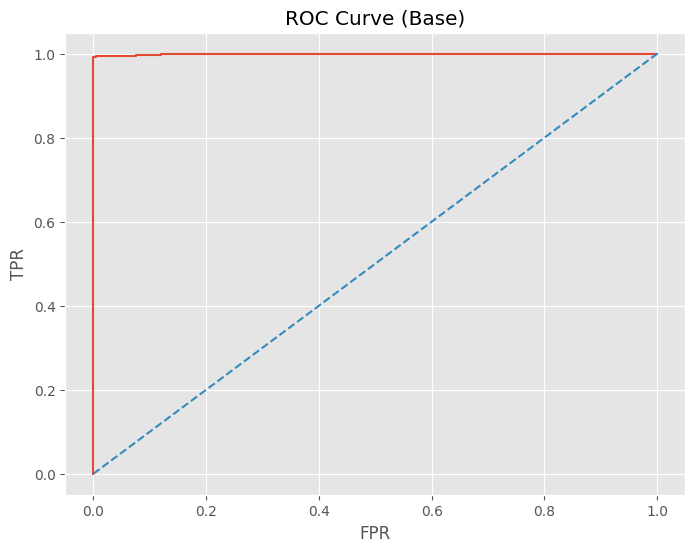

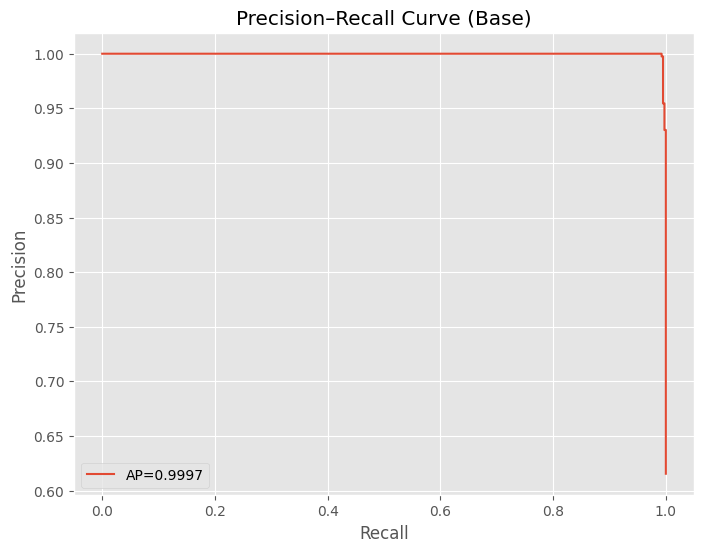

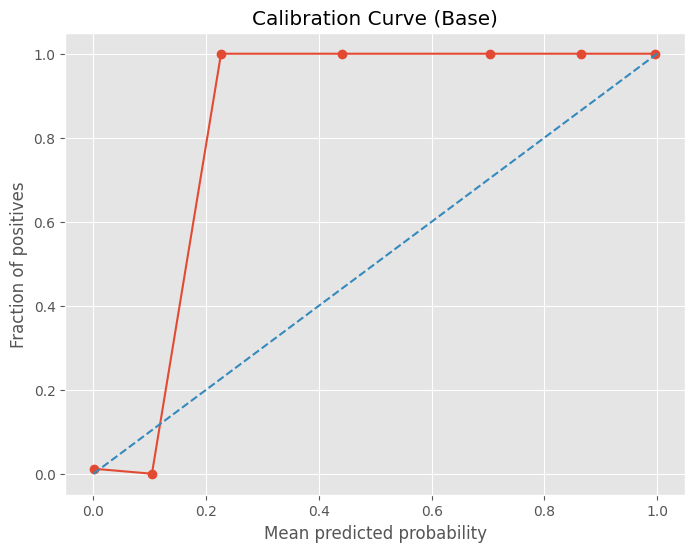

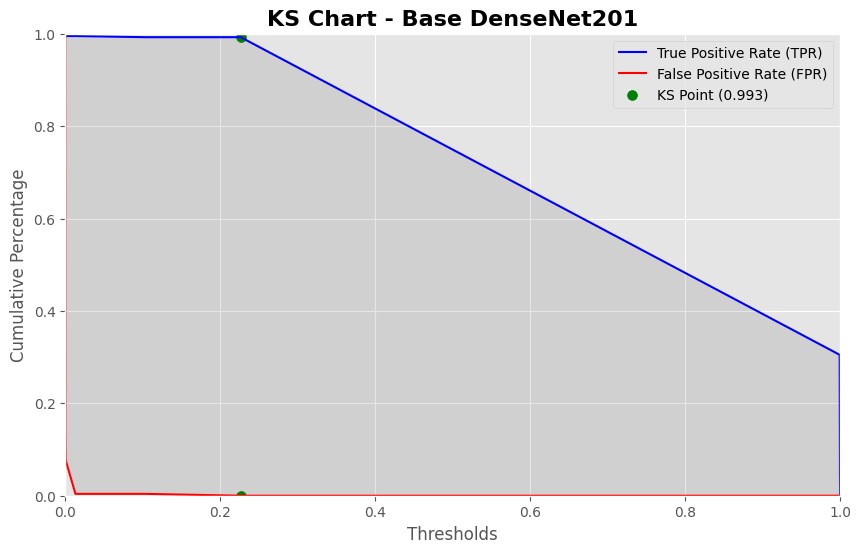

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0013723302399739623..0.001107220072299242].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0018241702346131206..0.001325748162344098].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0012061868328601122..0.0013399905292317271].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00252844812348485..0.002521179849281907].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0010353694669902325..0.0008101040730252862].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.002273119753226638..0.00254167593084

In [31]:
# Train model
mlflow.set_experiment("SolarPV_DenseNet201_Binary")
with mlflow.start_run(run_name="DenseNet201_Base_Frozen"):
    log_params()

    # train model
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=[earlystop, MLflowKerasCallback()]
    )

    plot_accuracy(history, "Training vs Validation Accuracy (Base)", "base_acc.png")
    plot_loss(history, "Training vs Validation Loss (Base)", "base_loss.png")
    plot_auc(history, "Training vs Validation AUC (Base)", "base_auc.png")
    y_true, y_pred_prob = eval_and_log_all(model, test_gen, run_prefix="base")
    y_pred = (y_pred_prob > 0.5).astype(int)

    get_classification_report(y_true, y_pred, test_gen.class_indices, "base_classification_report_base.txt")
    plot_confusion_matrix(y_true=y_true, y_pred=y_pred, class_indices=test_gen.class_indices,
                          filename="base_confusion_matrix.png", title="Confusion Matrix (Base)")

    plot_roc_curve(y_true, y_pred_prob, "ROC Curve (Base)", "base_roc.png")
    plot_pr_curve(y_true, y_pred_prob, "Precision–Recall Curve (Base)", "base_pr.png")
    plot_calibration_curve(y_true, y_pred_prob, "Calibration Curve (Base)", "base_calibration.png")

    plot_ks_chart(y_true, y_pred_prob, "Base DenseNet201", "base_ks.png")

    log_shap_images_to_mlflow(
        model=model,
        train_gen=train_gen,
        test_gen=test_gen,
        run_prefix="base",
        n_background=50,
        n_explain=10,
        artifact_dir="shap_base"
    )

    # Save model and log artifact
    model.save("base_model.keras")
    mlflow.log_artifact("base_model.keras")

    # Log class indices and dataset counts
    mlflow.log_param("class_indices", str(train_gen.class_indices))
    mlflow.log_param("train_class_counts", str(Counter(train_gen.classes)))
    mlflow.log_param("val_samples", val_gen.samples)
    mlflow.log_param("test_samples", test_gen.samples)

## 12. Model Architecture

We export:

- A layer diagram using `plot_model`, logged as an MLflow artifact.

And we also display a graph-style visualization using `visualkeras`

In [33]:
# Plot the model
plot_model(model, show_shapes=True, show_layer_names=True)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


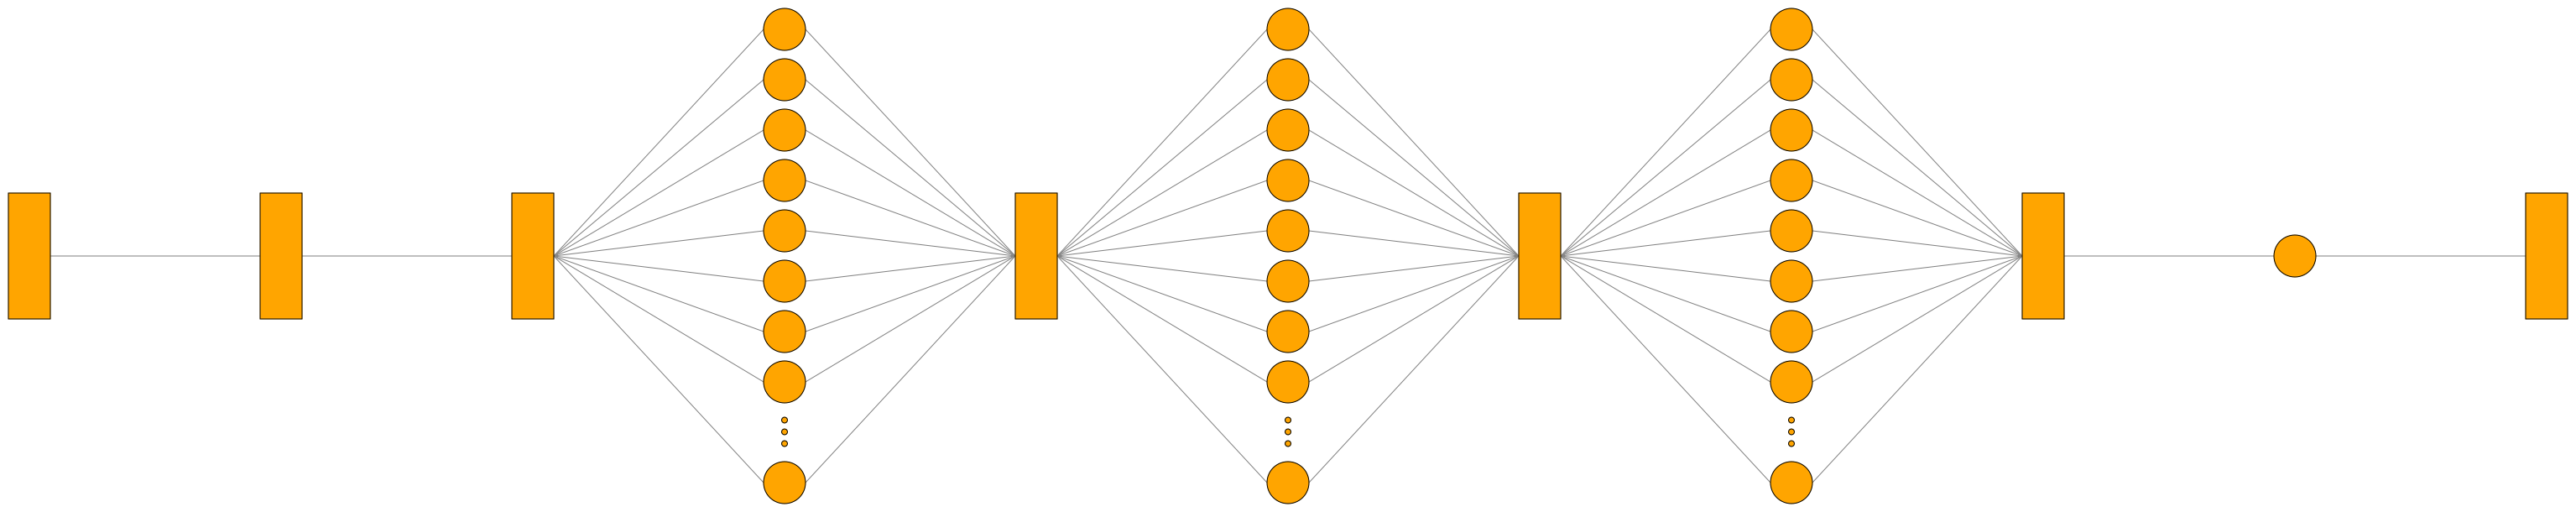

In [34]:
# View nodes
visualkeras.graph_view(
    model,
    background_fill='white'
)

In [35]:
# End based model run
mlflow.end_run()

## 13. Fine-tuning (Partial Unfreeze)

After training the head, we fine-tune the model by unfreezing the last **N** layers of DenseNet201 (here N=35).

Batch Normalization layers remain frozen because:

- BN statistics are sensitive and can destabilize fine-tuning on small datasets.
- Keeping BN frozen improves stability and generalization.

In [36]:
# Train last layers
for layer in base_model.layers[-35:]:
    layer.trainable = True

In [37]:
# Keep BatchNorm frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [38]:
# Compile new model
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='binary_crossentropy',
    metrics=['accuracy',
             AUC(name="auc"),
             Precision(name="precision"),
             Recall(name="recall")]
)

In [39]:
def log_params_tuned(epochs, unfreeze_last_n):
    mlflow.log_params({
        "IMG_SIZE": str(IMG_SIZE),
        "BATCH_SIZE": BATCH_SIZE,
        "EPOCHS": epochs,
        "base_model": "DenseNet201",
        "base_trainable": True,
        "unfreeze_last_n": unfreeze_last_n,
        "optimizer": "Adam",
        "loss": "binary_crossentropy",
        "earlystop_monitor": "val_auc",
        "earlystop_patience": 5,
    })

## 14. Training + Evaluation (Fine-tuned Model)

We train the partially-unfrozen DenseNet201 model for a smaller number of epochs.  
Then we repeat the same evaluation and explainability steps as the base run.  

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 200s 4s/step - accuracy: 0.9894 - auc: 0.9993 - loss: 0.0317 - precision: 0.9909 - recall: 0.9926 - val_accuracy: 0.9954 - val_auc: 0.9986 - val_loss: 0.0187 - val_precision: 1.0000 - val_recall: 0.9925
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 197s 5s/step - accuracy: 0.9967 - auc: 0.9992 - loss: 0.0147 - precision: 0.9960 - recall: 0.9989 - val_accuracy: 0.9630 - val_auc: 0.9985 - val_loss: 0.1122 - val_precision: 1.0000 - val_recall: 0.9400
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 206s 5s/step - accuracy: 0.9974 - auc: 0.9994 - loss: 0.0112 - precision: 0.9989 - recall: 0.9971 - val_accuracy: 0.9846 - val_auc: 0.9998 - val_loss: 0.0445 - val_precision: 1.0000 - val_recall: 0.9750
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 229s 5s/step - accuracy: 0.9993 - auc: 1.0000 - loss: 0.0045 - precision: 1.0000 - recall: 0.9989 - val_accuracy: 0.9846 - val_auc: 0.9986 - val_loss: 0.0516 - val_precision: 1.0000 - val_recall: 0.9750
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━

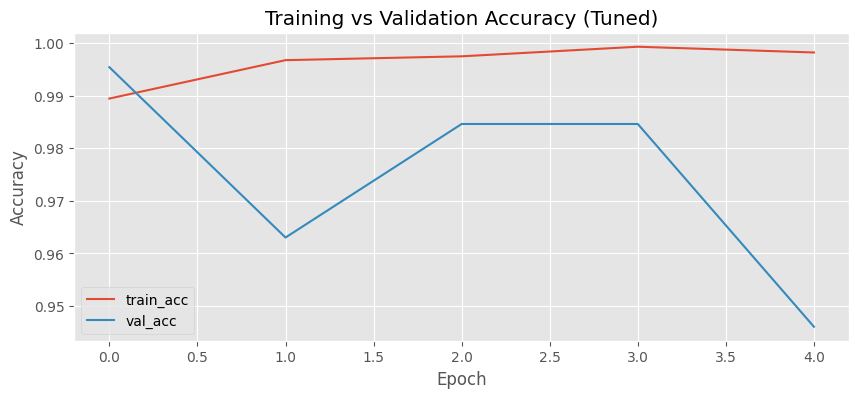

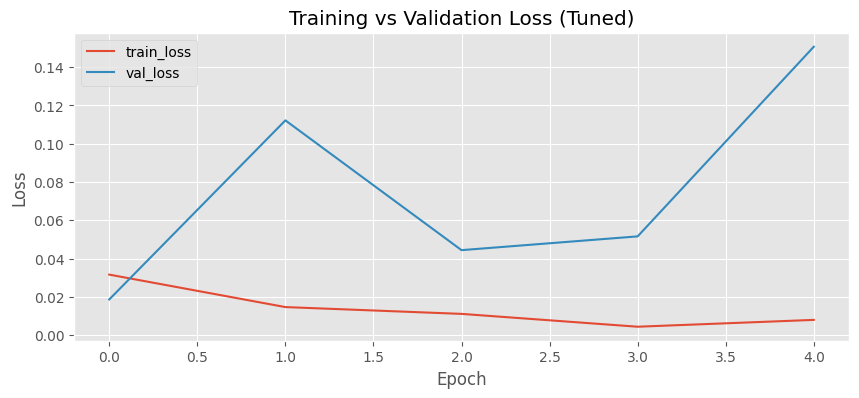

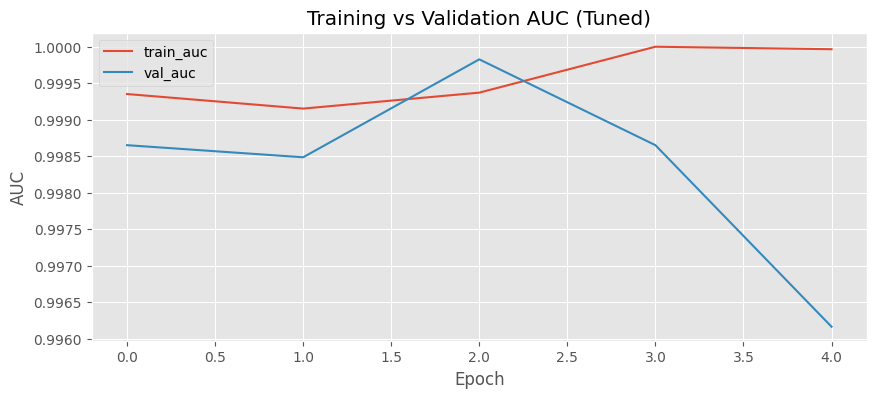

11/11 ━━━━━━━━━━━━━━━━━━━━ 51s 4s/step
                precision    recall  f1-score   support

         clean       0.99      1.00      0.99       250
single_hotspot       1.00      0.99      1.00       400

      accuracy                           1.00       650
     macro avg       0.99      1.00      1.00       650
  weighted avg       1.00      1.00      1.00       650



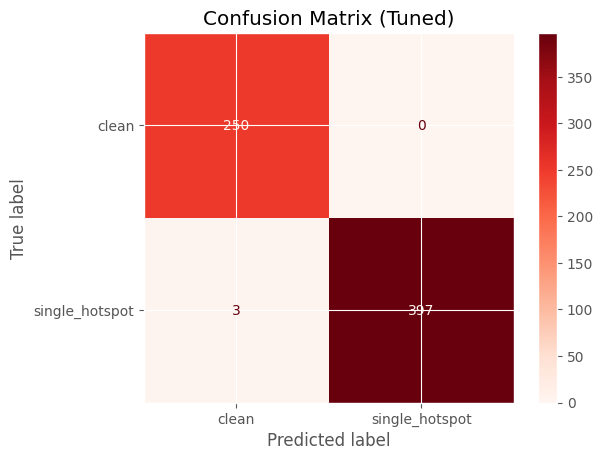

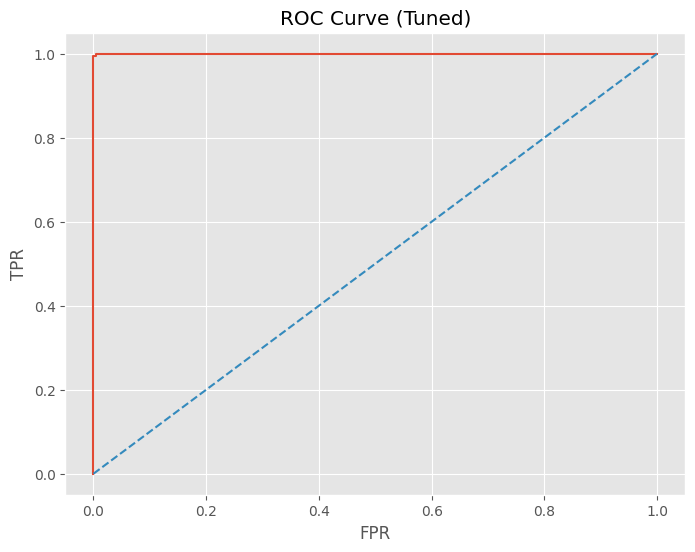

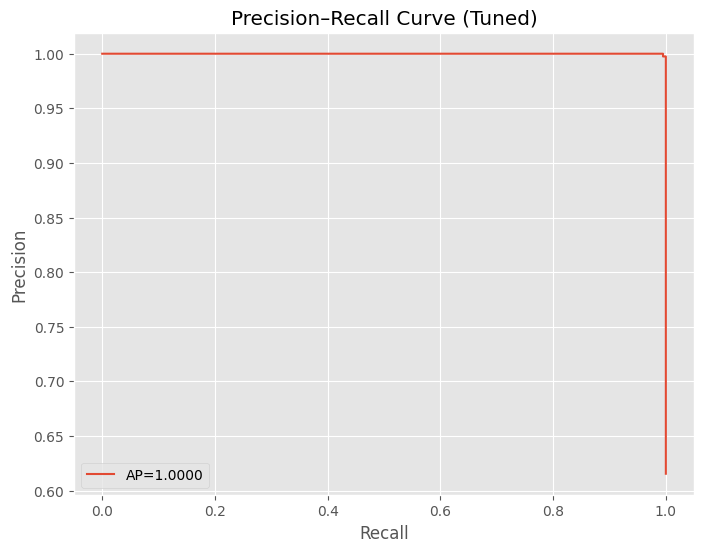

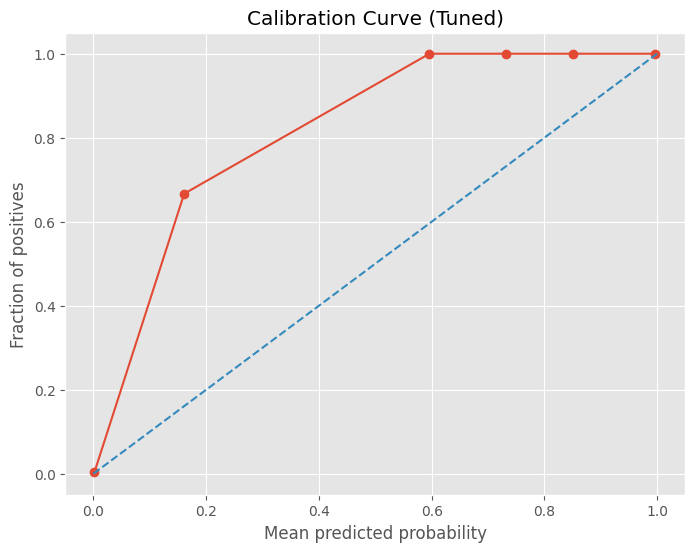

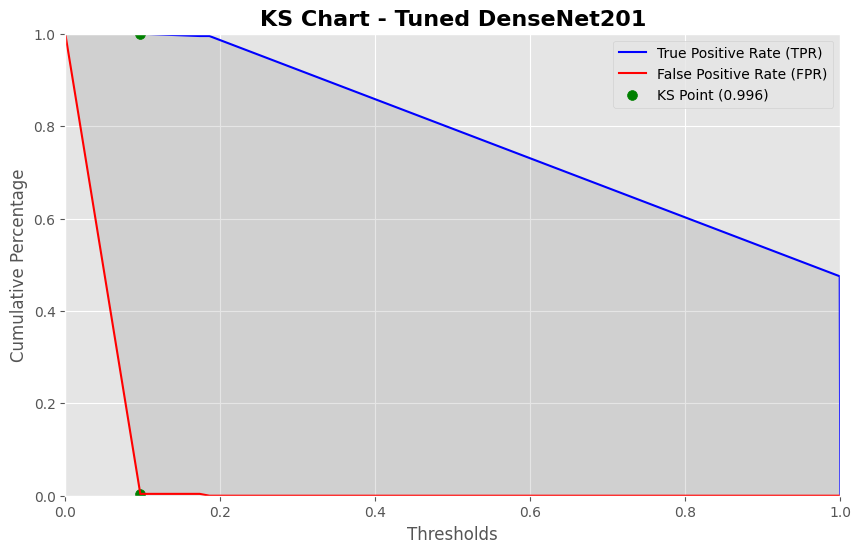

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0004796006251126528..0.0002792452578432858].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00046180057688616216..0.0004952914896421134].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0011118343099951744..0.0010281302966177464].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0019252864876762033..0.0017409613355994225].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0017355121672153473..0.0027075582183897495].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0013175560161471367..0.0020756

In [40]:
# Fine-tune
with mlflow.start_run(run_name="DenseNet201_Tuned"):
    log_params_tuned(epochs=10, unfreeze_last_n=35)

    tuned_history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=10,
        callbacks=[earlystop, MLflowKerasCallback()]
    )

    plot_accuracy(tuned_history, "Training vs Validation Accuracy (Tuned)", "tuned_acc.png")
    plot_loss(tuned_history, "Training vs Validation Loss (Tuned)", "tuned_loss.png")
    plot_auc(tuned_history, "Training vs Validation AUC (Tuned)", "tuned_auc.png")
    y_true, y_pred_prob_best = eval_and_log_all(model, test_gen, run_prefix="tuned")
    y_pred_best = (y_pred_prob_best > 0.5).astype(int)

    get_classification_report(y_true, y_pred_best, test_gen.class_indices, "classification_report_tuned.txt")
    plot_confusion_matrix(y_true=y_true, y_pred=y_pred_best, class_indices=test_gen.class_indices,
                          filename="tuned_confusion_matrix.png", title="Confusion Matrix (Tuned)")

    plot_roc_curve(y_true, y_pred_prob_best, "ROC Curve (Tuned)", "tuned_roc.png")
    plot_pr_curve(y_true, y_pred_prob_best, "Precision–Recall Curve (Tuned)", "tuned_pr.png")
    plot_calibration_curve(y_true, y_pred_prob_best, "Calibration Curve (Tuned)", "tuned_calibration.png")

    plot_ks_chart(y_true, y_pred_prob_best, "Tuned DenseNet201", "tuned_ks.png")

    log_shap_images_to_mlflow(
        model=model,
        train_gen=train_gen,
        test_gen=test_gen,
        run_prefix="tuned",
        n_background=50,
        n_explain=10,
        artifact_dir="shap_tuned"
    )

    model.save("tuned_model.keras")
    mlflow.log_artifact("tuned_model.keras")

## 15. Conclusion

The base DenseNet201 model achieved near-perfect classification performance. Fine-tuning the last 35 layers resulted in improved probability calibration (log loss and Brier score reduction) and slight gains in recall and KS statistic. Although performance gains were incremental due to the already strong baseline, the tuned model demonstrated improved generalization and confidence in fault detection.

Artifacts logged to MLflow include:

- Model files (`base_model.keras`, `tuned_model.keras`)
- Learning curves (accuracy/loss/auc)
- ROC, PR, calibration, KS charts
- Confusion matrices
- SHAP explanation images
- Classification reports